# Intrusion Detection System using Decision Tree
**KDD Dataset | Shifa Naaz**

In [4]:
import os
import pickle
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
warnings.filterwarnings('ignore')
print('Libraries loaded successfully!')

Libraries loaded successfully!


## 1. Load Dataset

In [5]:
# Find the KDD CSV file in Kaggle input
DATASET_PATH = None
for root, dirs, files in os.walk('/kaggle/input'):
    for file in files:
        if file.endswith('.csv'):
            DATASET_PATH = os.path.join(root, file)
            print(f'Found: {DATASET_PATH}')
            break
    if DATASET_PATH:
        break

if not DATASET_PATH:
    print('Dataset not found! Attach jayaprakashpondy/kdd-dataset on Kaggle.')

Found: /kaggle/input/datasets/jayaprakashpondy/kdd-dataset/kdd_train.csv


In [6]:
columns = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in',
    'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations',
    'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login',
    'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate',
    'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate',
    'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate',
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label'
]

# Load dataset — header=0 skips first row if it contains column names
df = pd.read_csv(DATASET_PATH, names=columns, header=0)

# Convert numeric columns
for col in df.columns:
    if col not in ['protocol_type', 'service', 'flag', 'label']:
        df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna().reset_index(drop=True)

print(f'Dataset shape: {df.shape}')
print(f'\nLabel distribution (top 10):')
print(df['label'].value_counts().head(10))

Dataset shape: (125973, 42)

Label distribution (top 10):
label
normal         67343
neptune        41214
satan           3633
ipsweep         3599
portsweep       2931
smurf           2646
nmap            1493
back             956
teardrop         892
warezclient      890
Name: count, dtype: int64


## 2. Data Visualization

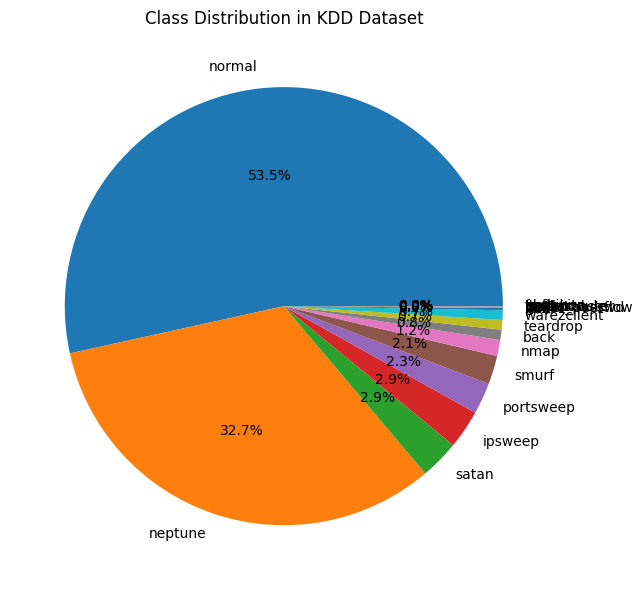

Class distribution saved!


In [7]:
label_counts = df['label'].value_counts()

plt.figure(figsize=(10, 6))
plt.pie(label_counts.values, labels=label_counts.index, autopct='%1.1f%%')
plt.title('Class Distribution in KDD Dataset')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Class distribution saved!')

## 3. Data Preprocessing

In [8]:
selected_features = [
    'protocol_type', 'flag', 'src_bytes', 'dst_bytes', 'hot',
    'count', 'srv_count', 'serror_rate', 'same_srv_rate',
    'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate',
    'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate'
]

X = df[selected_features].copy()
y = df['label'].copy()

# Encode categorical features
le_protocol = LabelEncoder()
le_flag = LabelEncoder()
X['protocol_type'] = le_protocol.fit_transform(X['protocol_type'].astype(str))
X['flag'] = le_flag.fit_transform(X['flag'].astype(str))

# Encode labels
le_label = LabelEncoder()
y_encoded = le_label.fit_transform(y)

print('Features shape:', X.shape)
print('Classes:', le_label.classes_)
print('\nFirst 5 rows:')
print(X.head())

Features shape: (125973, 16)
Classes: ['back' 'buffer_overflow' 'ftp_write' 'guess_passwd' 'imap' 'ipsweep'
 'land' 'loadmodule' 'multihop' 'neptune' 'nmap' 'normal' 'perl' 'phf'
 'pod' 'portsweep' 'rootkit' 'satan' 'smurf' 'spy' 'teardrop'
 'warezclient' 'warezmaster']

First 5 rows:
   protocol_type  flag  src_bytes  dst_bytes  hot  count  srv_count  \
0              1     9        491          0    0      2          2   
1              2     9        146          0    0     13          1   
2              1     5          0          0    0    123          6   
3              1     9        232       8153    0      5          5   
4              1     9        199        420    0     30         32   

   serror_rate  same_srv_rate  dst_host_count  dst_host_srv_count  \
0          0.0           1.00             150                  25   
1          0.0           0.08             255                   1   
2          1.0           0.05             255                  26   
3          

## 4. Train/Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)

print(f'Training samples: {X_train.shape[0]}')
print(f'Testing samples:  {X_test.shape[0]}')

Training samples: 100778
Testing samples:  25195


## 5. Train Decision Tree Model

In [10]:
model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=20,
    min_samples_split=5,
    random_state=42
)

model.fit(X_train, y_train)
print('Model trained successfully!')

train_acc = accuracy_score(y_train, model.predict(X_train))
print(f'Training Accuracy: {train_acc*100:.2f}%')

Model trained successfully!
Training Accuracy: 99.75%


## 6. Evaluate Model

In [11]:
y_pred = model.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)

print(f'Test Accuracy: {test_acc*100:.2f}%')
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=le_label.classes_))

Test Accuracy: 99.27%

Classification Report:
                 precision    recall  f1-score   support

           back       0.99      1.00      1.00       185
buffer_overflow       0.67      0.22      0.33         9
      ftp_write       0.00      0.00      0.00         0
   guess_passwd       1.00      0.91      0.95        11
           imap       0.50      1.00      0.67         1
        ipsweep       0.90      0.95      0.93       733
           land       0.20      0.67      0.31         3
     loadmodule       0.00      0.00      0.00         0
       multihop       0.00      0.00      0.00         0
        neptune       1.00      1.00      1.00      8228
           nmap       0.87      0.76      0.81       313
         normal       1.00      1.00      1.00     13422
           perl       0.00      0.00      0.00         1
            phf       1.00      1.00      1.00         1
            pod       1.00      0.93      0.96        43
      portsweep       0.99      0.99     

## 7. Confusion Matrix

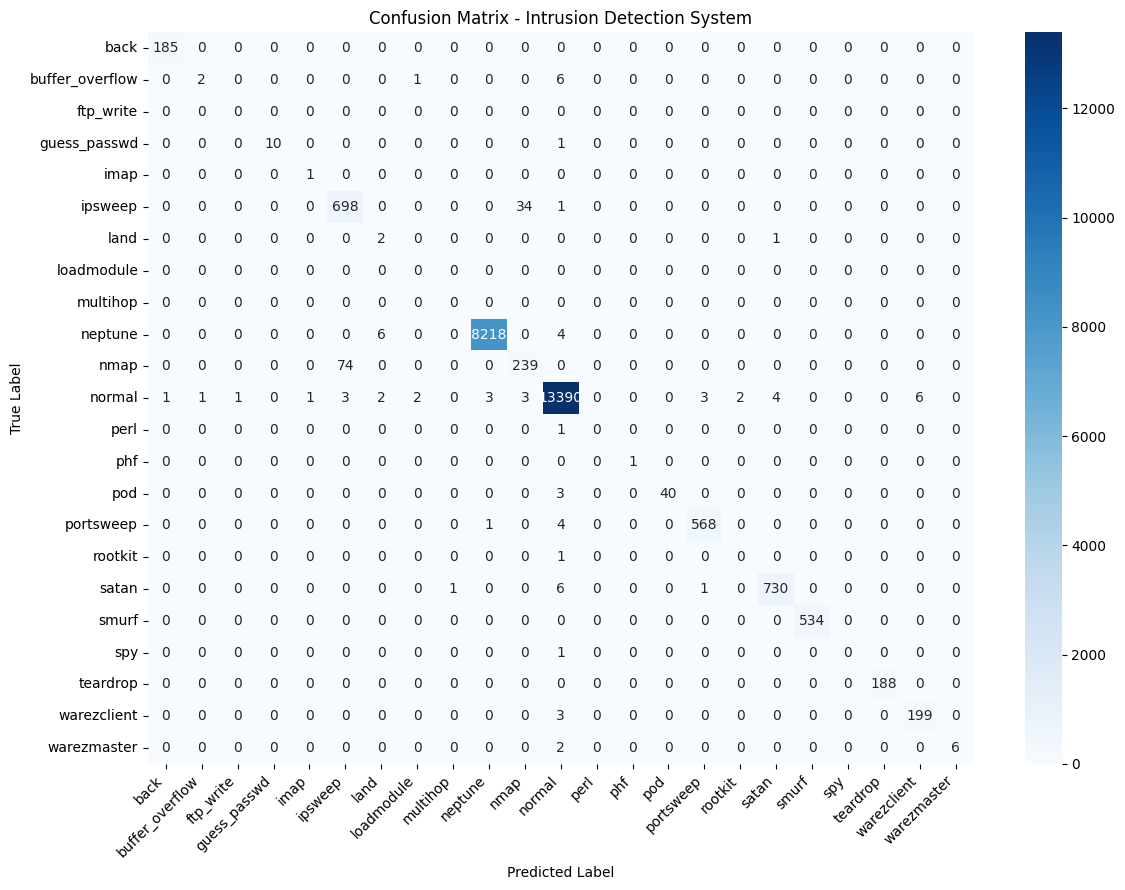

In [12]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12, 9))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_label.classes_,
            yticklabels=le_label.classes_)
plt.title('Confusion Matrix - Intrusion Detection System')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

## 8. Feature Importance

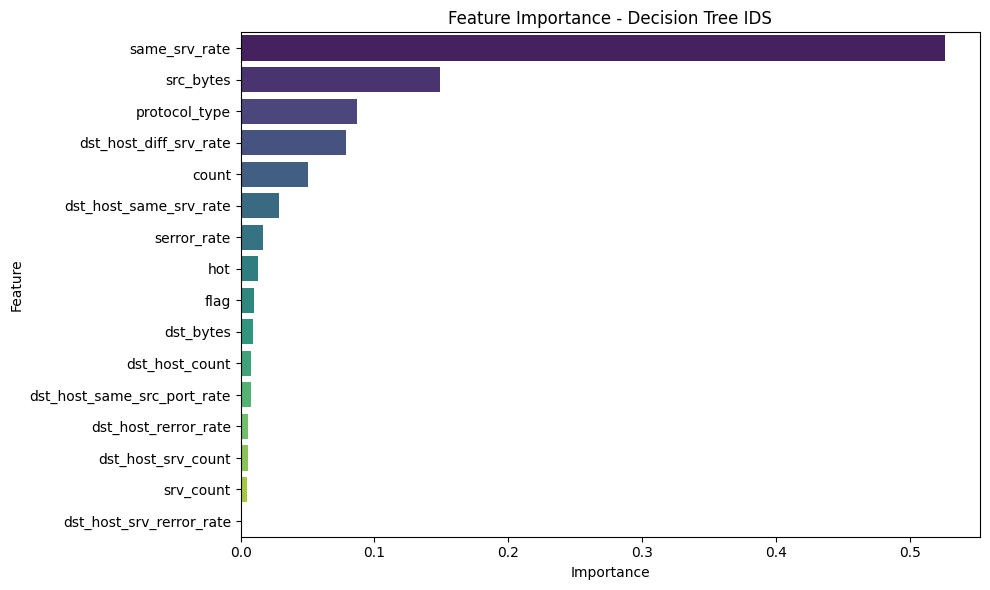

                    Feature  Importance
              same_srv_rate    0.526092
                  src_bytes    0.148623
              protocol_type    0.087198
     dst_host_diff_srv_rate    0.078552
                      count    0.050301
     dst_host_same_srv_rate    0.028797
                serror_rate    0.016373
                        hot    0.012764
                       flag    0.009607
                  dst_bytes    0.009088
             dst_host_count    0.008052
dst_host_same_src_port_rate    0.007797
       dst_host_rerror_rate    0.005678
         dst_host_srv_count    0.005510
                  srv_count    0.004689
   dst_host_srv_rerror_rate    0.000880


In [13]:
importance = pd.DataFrame({
    'Feature': selected_features,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance - Decision Tree IDS')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

print(importance.to_string(index=False))

## 9. Save Model

In [14]:
with open('ids_decision_tree.pkl', 'wb') as f:
    pickle.dump(model, f)

with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le_label, f)

print('Model saved: ids_decision_tree.pkl')
print(f'Final Test Accuracy: {test_acc*100:.2f}%')

Model saved: ids_decision_tree.pkl
Final Test Accuracy: 99.27%
